In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [27]:
df = pd.read_csv("Rent.csv")

In [28]:
df.head()

,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,10000.0,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,20000.0,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,17000.0,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,10000.0,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,7500.0,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727 entries, 0 to 4726
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4727 non-null   int64  
 1   Rent           4727 non-null   float64
 2   Size           4727 non-null   float64
 3   Floor          4727 non-null   int64  
 4   Area Locality  4727 non-null   int64  
 5   City           4727 non-null   int64  
 6   Bathroom       4727 non-null   float64
 7   N_11           4727 non-null   float64
 8   N_12           4727 non-null   float64
 9   N_13           4727 non-null   float64
 10  N_14           4727 non-null   float64
 11  N_15           4727 non-null   float64
 12  N_16           4727 non-null   float64
 13  N_17           4727 non-null   float64
 14  N_18           4727 non-null   float64
 15  N_19           4727 non-null   float64
 16  N_20           4727 non-null   float64
 17  N_21           4727 non-null   float64
 18  N_22    

In [30]:
df.isnull().sum()

BHK              0
Rent             0
Size             0
Floor            0
Area Locality    0
City             0
Bathroom         0
N_11             0
N_12             0
N_13             0
N_14             0
N_15             0
N_16             0
N_17             0
N_18             0
N_19             0
N_20             0
N_21             0
N_22             0
dtype: int64

In [31]:
x = df.drop(columns = ['Rent'])
y = df['Rent']

''' or
x = df.drop('Rent' , axis = 1)
y = df['Rent']
axis=1 means: Apply the operation on columns
axis=0 means apply on rows
'''

" or\nx = df.drop('Rent' , axis = 1)\ny = df['Rent']\naxis=1 means: Apply the operation on columns\naxis=0 means apply on rows\n"

In [32]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 35)

In [33]:
df['Rent']

0       10000.0
1       20000.0
2       17000.0
3       10000.0
4        7500.0
         ...   
4722    15000.0
4723    29000.0
4724    35000.0
4725    45000.0
4726    15000.0
Name: Rent, Length: 4727, dtype: float64

In [34]:
# ==============================================================================
# EXPLANATION: WHY WE RESHAPE 'y' BUT NOT 'X'
# ==============================================================================

# --- PART 1: Why didn't 'x_train' need reshaping? (No Error!) ---
# 'x_train' is a Pandas DataFrame (created when we dropped the 'Rent' column).
# A DataFrame is naturally a 2-Dimensional table (it has rows and columns).
# Since StandardScaler expects 2D tables by default, it accepts 'x_train' perfectly.
# No reshaping is needed!


# --- PART 2: Why does 'y_train' need .values.reshape(-1, 1)? ---
# 'y_train' is a Pandas Series (just a single column extracted like df['Rent']).
# Python sees a Series as a 1-Dimensional "flat list" of numbers, NOT a 2D table.
# StandardScaler refuses to work with 1D lists, so we must force it into a 2D shape.
# 
# What the code does:
#   1. .values          -> Strips away the Pandas labels, leaving raw numbers (NumPy array).
#   2. .reshape(-1, 1)  -> Turns the flat list into a vertical 2D column.
#                          (The '1' means "1 column", the '-1' means "auto-calculate rows").
#   3. .ravel()         -> After scaling is done, flattens it back so the Neural Network is happy.

In [35]:
# We scale x (features) because Neural Networks are very sensitive to different feature ranges.
# Example:
# Size may be 5000 while Bathrooms may be 2.
# Large-scale features can dominate training and make optimization unstable.

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Learn + apply on training data
x_train = scaler_x.fit_transform(x_train)
# ONLY apply same scaling to test data
x_test = scaler_x.transform(x_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test = scaler_y.transform(y_test.values.reshape(-1,1))
# .values.reshape(-1,1): converts Series to a 2D column array, required by StandardScaler

In [36]:
# We can ALSO scale y (Rent target) in regression problems.
# This is not always mandatory, but it is recommended for Neural Networks when target values are very large or have a wide range.
#
# Why?
# The model learns from y, and very large target values can produce huge loss values and unstable gradients during training.
#
# Scaling y helps:
# - faster convergence
# - more stable training
# - better optimization
#
# However, unlike X scaling, unscaled y usually does NOT completely break the model, which is why many beginner tutorials scale only X.

In [37]:
x_train

array([[ 1.12666881,  1.37999934,  1.2141987 , ..., -0.67521157,
        -0.016265  ,  0.67562674],
       [-0.08629667, -0.50887575,  0.74677653, ...,  1.48101727,
        -0.016265  , -1.48010719],
       [-0.08629667, -0.09282397,  1.44790979, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       ...,
       [-1.29926215, -0.75850682, -1.30742093, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       [-0.08629667, -0.59208611,  0.42696136, ...,  1.48101727,
        -0.016265  , -1.48010719],
       [-0.08629667, -0.34245504,  0.29165494, ..., -0.67521157,
        -0.016265  ,  0.67562674]])

In [38]:
x_test

array([[-0.08629667, -0.00961362,  1.34950512, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       [ 1.12666881,  1.73780387, -1.38737472, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       [-0.08629667, -0.50887575,  1.34950512, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       ...,
       [-1.29926215, -1.34097932,  0.27935435, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       [ 1.12666881,  2.0706453 ,  0.27935435, ..., -0.67521157,
        -0.016265  ,  0.67562674],
       [-1.29926215, -1.44083175,  1.39870746, ..., -0.67521157,
        -0.016265  ,  0.67562674]])

In [39]:
''' x_train is no longer a pandas DataFrame, it becomes a NumPy array
And: .head() exists only for pandas DataFrames, not NumPy arrays
NumPy arrays do NOT have:
.head()
.info()
.columns()
So you get an error.
'''

' x_train is no longer a pandas DataFrame, it becomes a NumPy array\nAnd: .head() exists only for pandas DataFrames, not NumPy arrays\nNumPy arrays do NOT have:\n.head()\n.info()\n.columns()\nSo you get an error.\n'

In [40]:
# This shows first 5 rows
x_train[:5]

array([[ 1.12666881,  1.37999934,  1.2141987 ,  0.53880859, -0.80161353,
         1.20355436, -0.02300523, -0.96184861,  0.96286821, -0.4156522 ,
         1.05409255, -0.78122125, -0.46238963, -1.62560201,  3.02720638,
        -0.67521157, -0.016265  ,  0.67562674],
       [-0.08629667, -0.50887575,  0.74677653,  0.36748358,  1.44100635,
         0.05931523, -0.02300523,  1.03966465, -1.03856373, -0.4156522 ,
        -0.9486833 ,  1.2800471 , -0.46238963, -1.62560201,  3.02720638,
         1.48101727, -0.016265  , -1.48010719],
       [-0.08629667, -0.09282397,  1.44790979, -0.50341859, -0.24095856,
         0.05931523, -0.02300523, -0.96184861,  0.96286821, -0.4156522 ,
         1.05409255, -0.78122125, -0.46238963,  0.61515672, -0.33033757,
        -0.67521157, -0.016265  ,  0.67562674],
       [-0.08629667, -1.11131874, -0.18806782, -0.20994518,  0.88035138,
        -1.0849239 , -0.02300523,  1.03966465, -1.03856373, -0.4156522 ,
        -0.9486833 ,  1.2800471 ,  2.16267824, -1.625

In [41]:
''' This creates an empty Neural Network model.
Sequential means: layers are added one after another in sequence.
'''
model = Sequential()

# Input + Hidden Layer
model.add(Dense(32 , activation = 'relu' , input_shape = x_train.shape[1:]))
# Second Hidden Laye
model.add(Dense(16 , activation = 'relu'))

# Output Layer
model.add(Dense(1 , activation = 'linear'))

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │             608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
'''
loss='mse' → what the model actually learns from
What it does:
The loss function is the signal the model uses to improve
It is minimized during training
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
metrics=['mae'] → just for monitoring performance
What it does:
Metrics are only for reporting
They do NOT affect training or weight updates
'''
model.compile(optimizer = 'adam' , loss = 'mse' , metrics = ['mae'])

'''
🧠 Simple analogy

Imagine you are studying:

Loss (MSE) → your exam score that decides if you pass or fail → you try to improve it
Metric (MAE) → feedback sheet showing how many mistakes you made on average → just for understanding
'''

'\n🧠 Simple analogy\n\nImagine you are studying:\n\nLoss (MSE) → your exam score that decides if you pass or fail → you try to improve it\nMetric (MAE) → feedback sheet showing how many mistakes you made on average → just for understanding\n'

In [43]:
early_stop = EarlyStopping(monitor = 'val_loss' , patience = 10 , restore_best_weights = True)

In [44]:
'''
history is a variable, it stores the result of training after training, it contains:
loss values per epoch
metrics (like MAE)
'''
history = model.fit(x_train , y_train , epochs = 100 , batch_size = 32 , validation_split = 0.2 , callbacks = [early_stop])

'''
“Train the model using x_train and y_train, for 100 full passes over the data, updating weights every 32 samples,
while using 20% of the data to check performance during training, and save all training results in history.”
'''

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0216 - mae: 0.4870 - val_loss: 0.4117 - val_mae: 0.3147
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5434 - mae: 0.3442 - val_loss: 0.3624 - val_mae: 0.3021
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4569 - mae: 0.3075 - val_loss: 0.3392 - val_mae: 0.2922
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4245 - mae: 0.2982 - val_loss: 0.3274 - val_mae: 0.2805
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4088 - mae: 0.2855 - val_loss: 0.3070 - val_mae: 0.2706
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3968 - mae: 0.2839 - val_loss: 0.3206 - val_mae: 0.2730
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3907 - mae: 0.2749 - val_loss: 0.3066 - val_mae: 0.2779
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3818 - mae: 0.2719 - val_loss: 0.2900 - val_mae: 0.2679
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.370

'\n“Train the model using x_train and y_train, for 100 full passes over the data, updating weights every 32 samples,\nwhile using 20% of the data to check performance during training, and save all training results in history.”\n'

In [45]:
y_pred = model.predict(x_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [46]:
mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)
print("MSE : " , mse)
print("MAE : " , mae)
print("R2 Score : " , r2)

MSE :  0.41170575548501975
MAE :  0.26744809816049275
R2 Score :  0.705252834682192


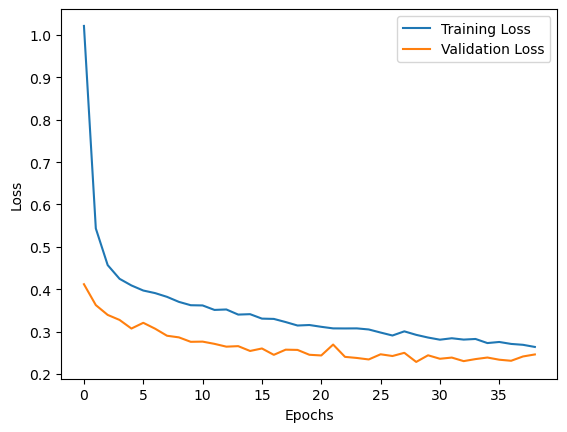

In [47]:
# loss, val_loss
# They are keys (labels) inside a dictionary
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Training Loss' , 'Validation Loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [48]:
model.evaluate(x_test , y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4117 - mae: 0.2674 


[0.41170576214790344, 0.2674480676651001]

In [49]:
# Inverse transform to get actual rent values
y_test_orig = scaler_y.inverse_transform(y_test)
y_pred_orig = scaler_y.inverse_transform(y_pred)

mse = mean_squared_error(y_test_orig, y_pred_orig)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print("Actual MAE (Rent Units):", mae)

MSE: 1235643985.35
MAE: 14651.86
R2 Score: 0.7053
Actual MAE (Rent Units): 14651.8588112071


In [50]:
# ============================================================
# REAL PREDICTION (on actual rent values)
# ============================================================

# Row 1 from dataset — actual rent is 10,000
sample = np.array([[2, 1100.0, 454, 220, 4, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]])
#                  BHK, Size, Floor, Locality, City, Bathroom, N_11 → N_22

# Scale the input the same way we scaled x_train
sample_scaled = scaler_x.transform(sample)

# Predict (result is still scaled)
pred_scaled = model.predict(sample_scaled)

# Convert back to real rent value
pred_real = scaler_y.inverse_transform(pred_scaled)

print(f"Actual Rent  : 10,000")
print(f"Predicted Rent: {pred_real[0][0]:,.0f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Actual Rent  : 10,000
Predicted Rent: 10,547


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
